# Simulação de Epidemias  
Disciplina: Ciência de Redes


### Integrantes
- Anderson Falcão
- Leonardo Alexandre  
- Ramyro Corrêa

---

#### Objetivo do Notebook

Este notebook contém a implementaçãoo das simulações do modelo **SIS (Suscetível-Infectado-Suscetível)** aplicado em dois tipos de redes:

- Rede aleatória
- Redes livre de escala

Ao longo do notebook, serão realizadas:

1. **Geração das redes** com 10.000 vértices e grau médio ≥ 20.  
2. **Simulações do processo epidêmico** para diferentes valores de β e μ.  
3. **Comparações entre simulações e resultados esperados pela teoria de campo médio.**  
4. **Estudo do limiar epidêmico: \( R_0 = \frac{\beta \langle k \rangle}{\mu} \).**  
5. **Experimentos de imunização** (aleatória, hubs e vizinhos) e análise da robustez da rede.

In [1]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

#### 1. Simulação do Modelo SIS em Rede Aleatória (ER)

Gere uma rede aleatória (ER) com $10000$ vértices e grau médio $\langle k \rangle = 20$. Comece
com $5$ vértices infectados escolhidos aleatoriamente. Execute múltiplas simulações da
propagação da infecção pelo modelo SIS com os parâmetros abaixo e compare com os
resultados esperados. (sugestão: faça em torno de 100 simulações e descreva o
comportamento da epidemia “na média”)

**a.** $\beta = 0.02$ e $\mu = 0.1\\$ 
**b.** $\beta = 0.02$ e $\mu = 0.4$  
**c.** $\beta = 0.02$ e $\mu = 0.5$  

Mostre que $R_0 = \frac{\beta \langle k \rangle}{\mu} > 1$,  então a doença se fixa na rede no modelo SIS de campo médio.

In [2]:
def simulate_sis(G, beta, mu, initial_infected=5, steps=200):
    nodes = list(G.nodes())
    
    # Estado inicial
    infected = set(random.sample(nodes, initial_infected))
    infected_history = []

    for t in range(steps):
        new_infected = set(infected)

        # infecta
        for node in infected:
            for neighbor in G.neighbors(node):
                if neighbor not in infected and random.random() < beta:
                    new_infected.add(neighbor)

        # recupera
        for node in list(new_infected):
            if random.random() < mu:
                new_infected.remove(node)

        infected = new_infected
        infected_history.append(len(infected) / len(nodes))

    return infected_history

In [3]:
def run_experiments(G, beta, mu, runs=100, steps=200):
    all_runs = []

    for _ in tqdm(range(runs), desc=f"β={beta}, μ={mu}"):
        hist = simulate_sis(G, beta, mu, steps=steps)
        all_runs.append(hist)

    mean_curve = np.mean(all_runs, axis=0)
    return mean_curve

In [4]:
N = 10000
k = 20
p = k / (N - 1)

G = nx.erdos_renyi_graph(N, p)
print("Rede ER gerada.")

Rede ER gerada.


In [5]:
params = [
    (0.02, 0.1),
    (0.02, 0.4),
    (0.02, 0.5)
]

results = {}

for beta, mu in params:
    mean_curve = run_experiments(G, beta, mu, runs=100, steps=200)
    results[(beta, mu)] = mean_curve

β=0.02, μ=0.5: 100%|██████████| 100/100 [00:00<00:00, 3868.39it/s]


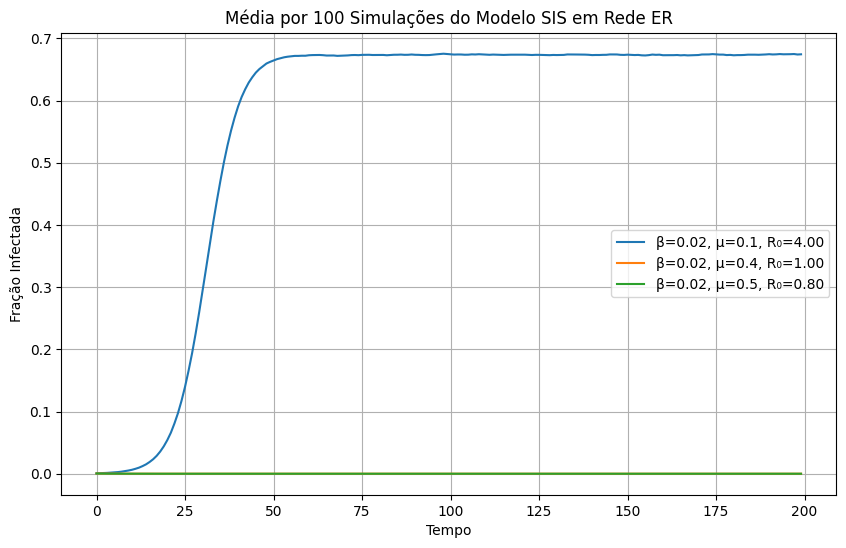

In [12]:
plt.figure(figsize=(10,6))

for (beta, mu), curve in results.items():
    R0 = beta * k / mu
    plt.plot(curve, label=f"β={beta}, μ={mu}, R₀={R0:.2f}")

plt.xlabel("Tempo")
plt.ylabel("Fração Infectada")
plt.title("Média por 100 Simulações do Modelo SIS em Rede ER")
plt.legend()
plt.grid(True)
plt.show()

#### 2. Simulação do Modelo SIS em Rede Livre de Escala

Gere uma rede “livre de escala” com 10000 vértices, grau médio $\langle k \rangle = 20$ e
expoente $\gamma = 2.5$. Comece com $5$ vértices infectados escolhidos aleatoriamente. Execute
múltiplas simulações da propagação da infecção pelo modelo SIS com os parâmetros abaixo e
compare com os resultados esperados. (sugestão: faça em torno de $100$ simulações e descreva
o comportamento da epidemia “na média”)

**a.** $\beta = 0.01$ e $\mu = 0.1 \\$
**b.** $\beta = 0.01$ e $\mu = 0.2 \\$
**c.** $\beta = 0.01$ e $\mu = 0.3$

Descreva o comportamento da epidemia e compare com o item (1).

In [17]:
N = 10000
k_target = 20
gamma = 2.5
 
deg_seq_float = nx.utils.powerlaw_sequence(N, exponent=gamma) # graus com distribuição power-law
mean_deg = sum(deg_seq_float) / N

In [18]:
# reescala para ter grau médio ~ k_target
scale = k_target / mean_deg
deg_seq = [max(1, int(round(d * scale))) for d in deg_seq_float]

# garante que a soma dos graus seja par
if sum(deg_seq) % 2 == 1:
    deg_seq[0] += 1

G_sf_multi = nx.configuration_model(deg_seq) # gera a rede livre de escala (multigrafo)
G_sf = nx.Graph(G_sf_multi)                     
G_sf.remove_edges_from(nx.selfloop_edges(G_sf)) 

# grau médio real da rede
avg_deg_sf = sum(dict(G_sf.degree()).values()) / G_sf.number_of_nodes()
print("Rede livre de escala gerada.")
print("N =", G_sf.number_of_nodes(), " | grau médio ≈", avg_deg_sf)


Rede livre de escala gerada.
N = 10000  | grau médio ≈ 18.039


In [19]:
params_sf = [(0.01, 0.1), (0.01, 0.2), (0.01, 0.3)]
results_sf = {}

for beta, mu in params_sf:
    mean_curve = run_experiments(G_sf, beta, mu, runs=100, steps=200)
    results_sf[(beta, mu)] = mean_curve

β=0.01, μ=0.3: 100%|██████████| 100/100 [00:18<00:00,  5.41it/s]


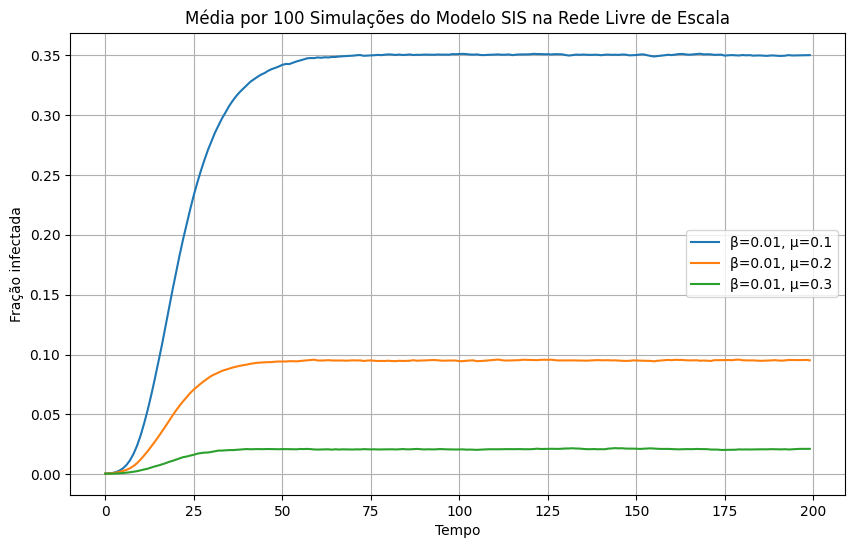

In [20]:
plt.figure(figsize=(10, 6)) 
for (beta, mu), curve in results_sf.items():
    plt.plot(curve, label=f"β={beta}, μ={mu}")
plt.xlabel("Tempo")
plt.ylabel("Fração infectada")
plt.title("Média por 100 Simulações do Modelo SIS na Rede Livre de Escala")
plt.legend()
plt.grid(True)
plt.show()